# 09b LSTM Hyperparameter Sweep

## Purpose
This notebook runs a systematic hyperparameter sweep over the LSTM architecture and training configuration from notebook `09`. The goal is to identify whether increasing early stopping patience, adding recurrent dropout, or lowering the learning rate improves F1 macro on the held-out test set.

The results of this sweep are used to update the configuration constants in notebook `09`, which then produces the final logged results. This notebook should be run once; it does not need to be rerun every time notebook `09` is executed.

## Sweep dimensions
Three hyperparameters are varied:

| Hyperparameter | Baseline | Candidates |
| --- | --- | --- |
| Early stopping patience | 10 | 20 |
| Recurrent dropout | 0.0 | 0.1 |
| Learning rate | 1e-3 | 5e-4 |

Four configurations are tested, each against all three lookback windows (L=30, 60, 90), for 12 MLflow runs total.

## Relation to other notebooks
- Uses the same data pipeline as `09_lstm.ipynb` (same split, same features, same target)
- Logs to the `lstm_sweep` MLflow experiment, separate from the `lstm_forecasting` experiment used by `09`
- Winner is applied to `09_lstm.ipynb` configuration and notebook `09` is rerun once to produce the final results

## Setup

In [1]:
import sys
import os
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2 as keras_l2

import mlflow

sys.path.append(str(Path.cwd().resolve().parent))
from mlflow_utils import get_or_create_experiment
from src.utils.plot_config import apply_plot_style

warnings.filterwarnings("ignore")
apply_plot_style()
mpl.rcParams["figure.facecolor"] = "#F9F7FC"
mpl.rcParams["axes.facecolor"]   = "#FFFFFF"
mpl.rcParams["font.family"]      = "sans-serif"

# Separate experiment so sweep runs do not clutter the main lstm experiment
EXPERIMENT_LSTM_SWEEP = "lstm_sweep"
get_or_create_experiment(EXPERIMENT_LSTM_SWEEP)
mlflow.set_experiment(EXPERIMENT_LSTM_SWEEP)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU") or "(none - running on CPU)")

I0000 00:00:1778953830.718511   48758 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778953832.494801   48758 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
GPU devices: (none - running on CPU)


E0000 00:00:1778953833.752069   48758 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


## Configuration

Fixed constants mirror notebook `09` exactly. Only the sweep dimensions vary.

In [2]:
PROJECT_ROOT           = Path.cwd().resolve().parent
DATA_PROCESSED_DIR     = PROJECT_ROOT / "data" / "processed"
DATA_MODEL_OUTPUTS_DIR = PROJECT_ROOT / "data" / "model_outputs"

LOG_RETURNS_PATH   = DATA_PROCESSED_DIR / "crypto_wide_log_returns_aligned.csv"
FEATURES_LONG_PATH = DATA_PROCESSED_DIR / "crypto_features_long_aligned.csv"
HMM_PATH           = DATA_MODEL_OUTPUTS_DIR / "hmm_regime_labels_k2.csv"
BASELINE_PATH      = DATA_MODEL_OUTPUTS_DIR / "baseline_predictions.csv"

# Fixed training constants (same as 09)
HORIZON             = 30
TEST_FRACTION       = 0.2
VAL_FRACTION_OF_TRAIN = 0.10
LOOKBACKS           = [30, 60, 90]
LSTM_UNITS          = 64
DENSE_UNITS         = 32
INPUT_DROPOUT       = 0.2
BATCH_SIZE          = 32
MAX_EPOCHS          = 100   # raised so early stopping drives termination

# Sweep grid: each dict is one configuration
SWEEP_CONFIGS = [
    {
        "label":             "baseline",
        "patience":          10,
        "recurrent_dropout": 0.0,
        "learning_rate":     1e-3,
        "reduce_lr":         False,
        "l2_reg":            0.0,
    },
    {
        "label":             "patience_20_recdrop01",
        "patience":          20,
        "recurrent_dropout": 0.1,
        "learning_rate":     1e-3,
        "reduce_lr":         False,
        "l2_reg":            0.0,
    },
    {
        "label":             "patience_20_recdrop01_reducelr",
        "patience":          20,
        "recurrent_dropout": 0.1,
        "learning_rate":     1e-3,
        "reduce_lr":         True,
        "l2_reg":            0.0,
    },
    {
        "label":             "patience_20_recdrop01_l2",
        "patience":          20,
        "recurrent_dropout": 0.1,
        "learning_rate":     1e-3,
        "reduce_lr":         False,
        "l2_reg":            1e-4,
    },
]

print(f"Sweep: {len(SWEEP_CONFIGS)} configs x {len(LOOKBACKS)} lookbacks = {len(SWEEP_CONFIGS) * len(LOOKBACKS)} MLflow runs")

Sweep: 4 configs x 3 lookbacks = 12 MLflow runs


## Load data

In [3]:
log_returns_df   = pd.read_csv(LOG_RETURNS_PATH, parse_dates=["Date"], index_col="Date")
features_long_df = pd.read_csv(FEATURES_LONG_PATH, parse_dates=["Date"])
hmm_df           = pd.read_csv(HMM_PATH, parse_dates=["Date"], index_col="Date")
baselines_df     = pd.read_csv(BASELINE_PATH, parse_dates=["Date"], index_col="Date")

print("Log returns:", log_returns_df.shape)
print("Features long:", features_long_df.shape)
print("HMM K=2:", hmm_df.shape)
print("04 baselines:", baselines_df.shape)

Log returns: (2174, 6)
Features long: (13044, 15)
HMM K=2: (2144, 3)
04 baselines: (423, 4)


## Build features, target, and split

Identical pipeline to notebook `09`. The target mask, dropna, and chronological split are all copied verbatim so the sweep runs on exactly the same data.

In [4]:
from src.features.daily import build_daily_market_features

daily_df = build_daily_market_features(features_long_df).dropna()

# Target construction (verbatim from 04)
def build_forward_target(btc_returns: pd.Series, horizon: int) -> pd.Series:
    """
    Binary target: 1 if the average BTC log return over the next horizon
    trading days is strictly positive, 0 otherwise.
    """
    forward_avg = btc_returns.shift(-1).rolling(window=horizon).mean().shift(-(horizon - 1))
    return (forward_avg > 0).astype("Int64")

btc_returns = log_returns_df["BTC"]
target = build_forward_target(btc_returns, HORIZON).rename("target")

# Restore tail rows with no valid forward window to NaN so they are dropped
forward_avg_check = btc_returns.shift(-1).rolling(window=HORIZON).mean().shift(-(HORIZON - 1))
target = target.mask(forward_avg_check.isna())

print("Target class balance:")
print(target.value_counts(dropna=False))

Target class balance:
target
1       1168
0        976
<NA>      30
Name: count, dtype: Int64


In [5]:
# HMM features
hmm_oh = pd.get_dummies(hmm_df["hmm_regime"], prefix="hmm_state").astype(int)
hmm_post_cols = [c for c in hmm_df.columns if c.startswith("hmm_prob_state_")]
hmm_post = hmm_df[hmm_post_cols]

data = (
    daily_df
    .join(hmm_oh, how="inner")
    .join(hmm_post, how="inner")
    .join(target, how="inner")
)
data["hmm_regime"] = hmm_df["hmm_regime"]

data = data.dropna(subset=daily_df.columns.tolist() + ["target"])
data["target"] = data["target"].astype(int)

BASE_FEATURES = [
    "mean_log_return", "return_dispersion", "mean_volatility",
    "mean_btc_corr", "mean_idio_vol",
    "dxy_log_return", "gold_log_return", "sp500_log_return", "vix_log_return",
]
HMM_FEATURES = [c for c in data.columns if c.startswith("hmm_state_")] + hmm_post_cols
FEATURES = BASE_FEATURES + HMM_FEATURES

print("Final dataset:", data.shape)
print(f"Date range: {data.index.min().date()} to {data.index.max().date()}")
print(f"Feature count: {len(FEATURES)}")

Final dataset: (2114, 15)
Date range: 2020-05-10 to 2026-02-21
Feature count: 13


In [6]:
split_idx  = int(len(data) * (1 - TEST_FRACTION))
train_data = data.iloc[:split_idx]
test_data  = data.iloc[split_idx:]

print(f"Train: {len(train_data)} rows | {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Test:  {len(test_data)} rows | {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"\nTest class balance:\n{test_data['target'].value_counts().sort_index()}")

# Sanity check against notebook 04 baselines
baselines_aligned = baselines_df.loc[test_data.index]
assert (baselines_aligned["y_true"].to_numpy() == test_data["target"].to_numpy()).all(), \
    "Test labels disagree with baseline_predictions.csv."
print("\n[OK] Test labels match 04 baselines exactly.")

Train: 1691 rows | 2020-05-10 to 2024-12-25
Test:  423 rows | 2024-12-26 to 2026-02-21

Test class balance:
target
0    235
1    188
Name: count, dtype: int64

[OK] Test labels match 04 baselines exactly.


## Sequence builder and model factory

Both functions are copied verbatim from notebook `09`. The model factory accepts `recurrent_dropout` and `learning_rate` as parameters so each sweep configuration can vary them independently.

In [7]:
def build_sequences(values: np.ndarray, targets: np.ndarray, window: int):
    """
    values:  (T, F) array of feature rows, oldest first
    targets: (T,) array of binary labels aligned with values
    window:  L

    Returns (X, y, idx) where:
      X   shape (T - window + 1, window, F)
      y   shape (T - window + 1,)        - target at each window's last row
      idx shape (T - window + 1,)        - the original time index of each window's last row
    """
    n = len(values) - window + 1
    X = np.empty((n, window, values.shape[1]), dtype=np.float32)
    y = np.empty(n, dtype=np.int32)
    idx = np.arange(window - 1, len(values))
    for i in range(n):
        X[i] = values[i : i + window]
        y[i] = targets[i + window - 1]
    return X, y, idx


def build_sweep_lstm(
    input_shape: tuple,
    recurrent_dropout: float,
    learning_rate: float,
    l2_reg: float = 0.0,
) -> Sequential:
    """
    Build and compile an LSTM with the given hyperparameters.
    l2_reg applies L2 regularization to both the input and recurrent
    weight matrices. Set to 0.0 to disable.
    """
    reg = keras_l2(l2_reg) if l2_reg > 0 else None
    model = Sequential([
        Input(shape=input_shape),
        LSTM(
            LSTM_UNITS,
            dropout=INPUT_DROPOUT,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=reg,
            recurrent_regularizer=reg,
        ),
        Dropout(INPUT_DROPOUT),
        Dense(DENSE_UNITS, activation="relu"),
        Dropout(INPUT_DROPOUT),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def prepare_for_lookback(L: int) -> dict:
    """Scale features and build sequences. Scaler is fit on train only."""
    scaler = StandardScaler().fit(train_data[FEATURES].values)

    full_scaled = pd.DataFrame(
        scaler.transform(data[FEATURES].values),
        index=data.index,
        columns=FEATURES,
    )
    full_targets = data["target"].to_numpy()

    X_all, y_all, idx_all = build_sequences(full_scaled.values, full_targets, L)
    target_dates = data.index[idx_all]

    is_test  = target_dates.isin(test_data.index)
    is_train = ~is_test

    X_train_full = X_all[is_train]
    y_train_full = y_all[is_train]
    X_test       = X_all[is_test]
    y_test       = y_all[is_test]
    test_dates   = target_dates[is_test]

    val_size = int(len(X_train_full) * VAL_FRACTION_OF_TRAIN)
    X_train = X_train_full[:-val_size]
    X_val   = X_train_full[-val_size:]
    y_train = y_train_full[:-val_size]
    y_val   = y_train_full[-val_size:]

    return {
        "X_train": X_train, "y_train": y_train,
        "X_val":   X_val,   "y_val":   y_val,
        "X_test":  X_test,  "y_test":  y_test,
        "test_dates": test_dates,
    }

## Run the sweep

Each configuration is crossed with each lookback window. Every combination is one MLflow run. All runs are logged under the `lstm_sweep` experiment so they stay separate from notebook `09`'s runs.

In [8]:
sweep_results = []

for cfg in SWEEP_CONFIGS:
    for L in LOOKBACKS:
        bundle  = prepare_for_lookback(L)
        X_train = bundle["X_train"]
        y_train = bundle["y_train"]
        X_val   = bundle["X_val"]
        y_val   = bundle["y_val"]
        X_test  = bundle["X_test"]
        y_test  = bundle["y_test"]

        classes_present = np.unique(y_train)
        weights = compute_class_weight("balanced", classes=classes_present, y=y_train)
        class_weight = dict(zip(classes_present.tolist(), weights.tolist()))

        tf.keras.utils.set_random_seed(SEED)
        model = build_sweep_lstm(
            input_shape=(L, len(FEATURES)),
            recurrent_dropout=cfg["recurrent_dropout"],
            learning_rate=cfg["learning_rate"],
            l2_reg=cfg["l2_reg"],
        )

        callbacks = [
            EarlyStopping(
                monitor="val_loss",
                patience=cfg["patience"],
                restore_best_weights=True,
                verbose=0,
            )
        ]
        if cfg["reduce_lr"]:
            callbacks.append(
                ReduceLROnPlateau(
                    monitor="val_loss",
                    factor=0.5,
                    patience=5,
                    min_lr=1e-5,
                    verbose=0,
                )
            )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            class_weight=class_weight,
            callbacks=callbacks,
            verbose=0,
        )
        epochs_run = len(history.history["loss"])

        proba = model.predict(X_test, verbose=0).ravel()
        preds = (proba > 0.5).astype(int)

        acc = accuracy_score(y_test, preds)
        f1  = f1_score(y_test, preds, average="macro")
        prec = precision_score(y_test, preds, average="macro", zero_division=0)
        rec  = recall_score(y_test, preds, average="macro", zero_division=0)

        run_name = f"{cfg['label']}_L{L}"
        with mlflow.start_run(run_name=run_name):
            mlflow.log_params({
                "config_label":       cfg["label"],
                "lookback":           L,
                "patience":           cfg["patience"],
                "recurrent_dropout":  cfg["recurrent_dropout"],
                "learning_rate":      cfg["learning_rate"],
                "reduce_lr":          cfg["reduce_lr"],
                "l2_reg":             cfg["l2_reg"],
                "lstm_units":         LSTM_UNITS,
                "dense_units":        DENSE_UNITS,
                "input_dropout":      INPUT_DROPOUT,
                "batch_size":         BATCH_SIZE,
                "max_epochs":         MAX_EPOCHS,
                "epochs_run":         epochs_run,
                "seed":               SEED,
            })
            mlflow.log_metrics({
                "accuracy":         acc,
                "f1_macro":         f1,
                "precision_macro":  prec,
                "recall_macro":     rec,
                "final_val_loss":   float(min(history.history["val_loss"])),
                "final_train_loss": float(history.history["loss"][-1]),
            })

        sweep_results.append({
            "config":             cfg["label"],
            "lookback":           L,
            "patience":           cfg["patience"],
            "recurrent_dropout":  cfg["recurrent_dropout"],
            "learning_rate":      cfg["learning_rate"],
            "epochs_run":         epochs_run,
            "accuracy":           acc,
            "f1_macro":           f1,
            "precision_macro":    prec,
            "recall_macro":       rec,
        })

        print(f"{run_name:45s}  f1={f1:.4f}  acc={acc:.4f}  epochs={epochs_run}")

sweep_df = pd.DataFrame(sweep_results)
print(f"\nTotal runs: {len(sweep_df)}")

baseline_L30                                   f1=0.4270  acc=0.4279  epochs=16
baseline_L60                                   f1=0.5414  acc=0.5414  epochs=12
baseline_L90                                   f1=0.5020  acc=0.5130  epochs=15
patience_20_recdrop01_L30                      f1=0.3650  acc=0.3877  epochs=34
patience_20_recdrop01_L60                      f1=0.5279  acc=0.5461  epochs=21
patience_20_recdrop01_L90                      f1=0.6099  acc=0.6099  epochs=25
patience_20_recdrop01_reducelr_L30             f1=0.3626  acc=0.3664  epochs=39
patience_20_recdrop01_reducelr_L60             f1=0.5279  acc=0.5461  epochs=21
patience_20_recdrop01_reducelr_L90             f1=0.6099  acc=0.6099  epochs=25
patience_20_recdrop01_l2_L30                   f1=0.3643  acc=0.3759  epochs=39
patience_20_recdrop01_l2_L60                   f1=0.4797  acc=0.4799  epochs=28
patience_20_recdrop01_l2_L90                   f1=0.4702  acc=0.4704  epochs=28

Total runs: 12


## Results

In [9]:
# Full results table sorted by F1 macro
results_table = sweep_df.set_index(["config", "lookback"]).sort_values("f1_macro", ascending=False)
print("Full sweep results (sorted by F1 macro):")
results_table[["patience", "recurrent_dropout", "learning_rate",
               "epochs_run", "accuracy", "f1_macro"]].round(4)

Full sweep results (sorted by F1 macro):


patience  recurrent_dropout  \
config                         lookback                                
patience_20_recdrop01          90              20                0.1   
patience_20_recdrop01_reducelr 90              20                0.1   
baseline                       60              10                0.0   
patience_20_recdrop01          60              20                0.1   
patience_20_recdrop01_reducelr 60              20                0.1   
baseline                       90              10                0.0   
patience_20_recdrop01_l2       60              20                0.1   
                               90              20                0.1   
baseline                       30              10                0.0   
patience_20_recdrop01          30              20                0.1   
patience_20_recdrop01_l2       30              20                0.1   
patience_20_recdrop01_reducelr 30              20                0.1   

                                         learning_rate  epochs_run  accuracy  \
config                         lookback                                        
patience_20_recdrop01          90                0.001          25    0.6099   
patience_20_recdrop01_reducelr 90                0.001          25    0.6099   
baseline                       60                0.001          12    0.5414   
patience_20_recdrop01          60                0.001          21    0.5461   
patience_20_recdrop01_reducelr 60                0.001          21    0.5461   
baseline                       90                0.001          15    0.5130   
patience_20_recdrop01_l2       60                0.001          28    0.4799   
                               90                0.001          28    0.4704   
baseline                       30                0.001          16    0.4279   
patience_20_recdrop01          30                0.001          34    0.3877   
patience_20_recdrop01_l2       30                0.001          39    0.3759   
patience_20_recdrop01_reducelr 30                0.001          39    0.3664   

                                         f1_macro  
config                         lookback            
patience_20_recdrop01          90          0.6099  
patience_20_recdrop01_reducelr 90          0.6099  
baseline                       60          0.5414  
patience_20_recdrop01          60          0.5279  
patience_20_recdrop01_reducelr 60          0.5279  
baseline                       90          0.5020  
patience_20_recdrop01_l2       60          0.4797  
                               90          0.4702  
baseline                       30          0.4270  
patience_20_recdrop01          30          0.3650  
patience_20_recdrop01_l2       30          0.3643  
patience_20_recdrop01_reducelr 30          0.3626

In [10]:
# Best F1 per config (across all lookbacks) to compare configurations directly
best_per_config = (
    sweep_df.groupby("config")[["f1_macro", "accuracy"]]
    .max()
    .sort_values("f1_macro", ascending=False)
)
print("Best F1 per configuration (max over all lookbacks):")
best_per_config.round(4)

Best F1 per configuration (max over all lookbacks):


,f1_macro,accuracy
config,,
patience_20_recdrop01,0.6099,0.6099
patience_20_recdrop01_reducelr,0.6099,0.6099
baseline,0.5414,0.5414
patience_20_recdrop01_l2,0.4797,0.4799


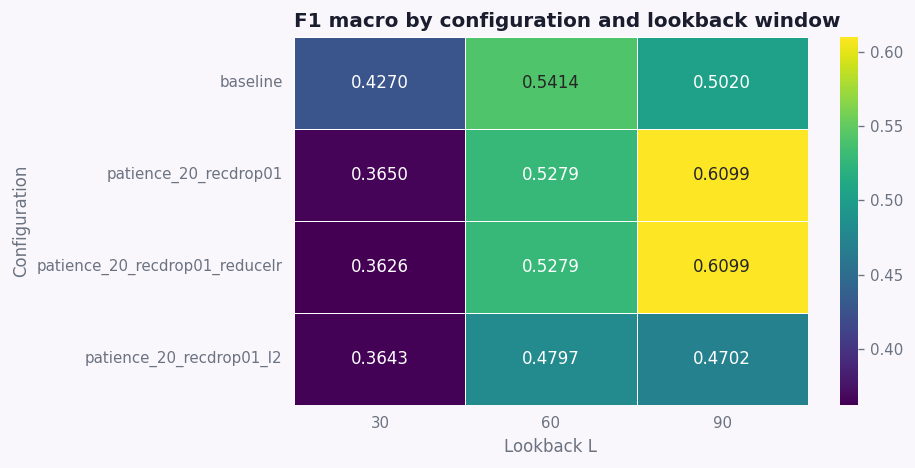

In [11]:
# Heatmap: F1 macro by config and lookback for quick visual comparison
pivot = sweep_df.pivot(index="config", columns="lookback", values="f1_macro")

# Keep the config order matching SWEEP_CONFIGS for readability
config_order = [c["label"] for c in SWEEP_CONFIGS]
pivot = pivot.loc[config_order]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    vmin=pivot.values.min(),
    vmax=pivot.values.max(),
    ax=ax,
    linewidths=0.5,
)
ax.set_title("F1 macro by configuration and lookback window")
ax.set_xlabel("Lookback L")
ax.set_ylabel("Configuration")
plt.tight_layout()
plt.show()

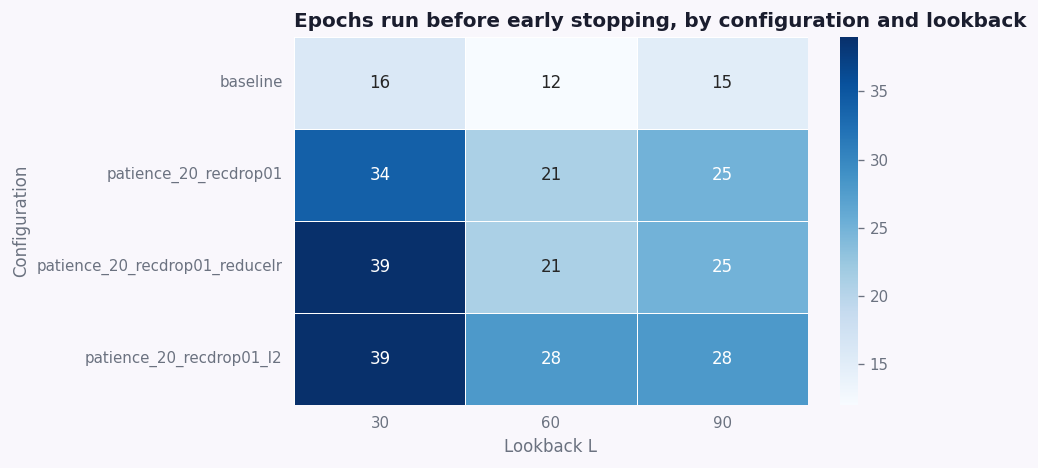

In [12]:
# Epochs run per config: shorter = early stopping triggered earlier = noisier training
pivot_epochs = sweep_df.pivot(index="config", columns="lookback", values="epochs_run")
pivot_epochs = pivot_epochs.loc[config_order]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot_epochs,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Epochs run before early stopping, by configuration and lookback")
ax.set_xlabel("Lookback L")
ax.set_ylabel("Configuration")
plt.tight_layout()
plt.show()

## Winner and recommendation

The cell below identifies the single best configuration by F1 macro and prints the constants to copy into notebook `09`.

In [13]:
best_row = sweep_df.loc[sweep_df["f1_macro"].idxmax()]

print("=" * 60)
print("WINNER")
print("=" * 60)
print(f"Config:            {best_row['config']}")
print(f"Lookback:          {int(best_row['lookback'])}")
print(f"F1 macro:          {best_row['f1_macro']:.4f}")
print(f"Accuracy:          {best_row['accuracy']:.4f}")
print(f"Epochs run:        {int(best_row['epochs_run'])}")
print()
print("Copy these constants into notebook 09's configuration cell:")
print()
print(f"EARLY_STOP_PATIENCE = {int(best_row['patience'])}")
print(f"LEARNING_RATE       = {best_row['learning_rate']}")
print(f"# recurrent_dropout = {best_row['recurrent_dropout']}  (set inside build_lstm)")
print()

# Baseline comparison
baseline_row = sweep_df.loc[
    (sweep_df["config"] == "baseline") & (sweep_df["lookback"] == int(best_row["lookback"]))
].iloc[0]

delta_f1  = best_row["f1_macro"]  - baseline_row["f1_macro"]
delta_acc = best_row["accuracy"]  - baseline_row["accuracy"]
print(f"Delta vs baseline at same lookback (L={int(best_row['lookback'])}):")
print(f"  d_f1_macro = {delta_f1:+.4f}")
print(f"  d_accuracy = {delta_acc:+.4f}")

WINNER
Config:            patience_20_recdrop01
Lookback:          90
F1 macro:          0.6099
Accuracy:          0.6099
Epochs run:        25

Copy these constants into notebook 09's configuration cell:

EARLY_STOP_PATIENCE = 20
LEARNING_RATE       = 0.001
# recurrent_dropout = 0.1  (set inside build_lstm)

Delta vs baseline at same lookback (L=90):
  d_f1_macro = +0.1080
  d_accuracy = +0.0969


<div class="alert alert-block alert-info"><b>Note:</b>
A second sweep round tested ReduceLROnPlateau and L2 weight regularization against the current winner. ReduceLROnPlateau produced identical results because early stopping fires before the callback has time to act meaningfully. L2 regularization reduced F1 from 0.6099 to 0.4702 at L=90, indicating that recurrent_dropout=0.1 already provides sufficient regularization and additional weight penalties over-constrain the model. The winning configuration from the first sweep (patience=20, recurrent_dropout=0.1, lr=1e-3, L=90) is confirmed as the final choice. Further improvements are constrained by the training set size of 1691 sequences.
</div>

## Limitations

- The sweep selects the best configuration based on test set performance. This is an acknowledged limitation: the test set is used both for evaluation and for configuration selection. Reporting all 12 results rather than just the winner is the transparent approach.
- Only three hyperparameters were varied. Batch size, number of LSTM units, and dense layer width were held fixed to keep the search tractable.
- Each configuration is trained with a single random seed. Variance across seeds is not measured.